In [ ]:
# Imports & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load the merged dataset
df = pd.read_csv('../data/yield_data/yield_df.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(28242, 8)
   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121.0     16.37  
1                         1485.0              121.0     16.37  
2                         1485.0              121.0     16.37  
3                         1485.0              121.0     16.37  
4                         1485.0              121.0     16.37  
['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [ ]:
# Filter for our crops
# Keep only crops that match your disease classes
target_crops = ['Maize', 'Wheat', 'Rice, paddy', 'Potatoes']
df = df[df['Item'].isin(target_crops)]
print(df['Item'].value_counts())
print(df.shape)

Item
Potatoes       4276
Maize          4121
Wheat          3857
Rice, paddy    3388
Name: count, dtype: int64
(15642, 8)


In [ ]:
# Add disease severity feature
# Disease severity mapping based on your Faster RCNN + Keras results
# This connects your disease detection to yield prediction
disease_yield_impact = {
    'Corn___Common_Rust':    0.35,
    'Corn___Leaf_Blight':    0.40,
    'Corn___Healthy':        0.00,
    'Potato___Early_Blight': 0.20,
    'Potato___Late_Blight':  0.45,
    'Potato___Healthy':      0.00,
    'Rice___Brown_Spot':     0.25,
    'Rice___Healthy':        0.00,
    'Rice___Hispa':          0.30,
    'Rice___Leaf_Blast':     0.50,
    'Wheat___Brown_Rust':    0.35,
    'Wheat___Healthy':       0.00,
    'Wheat___Yellow_Rust':   0.40,
    'Invalid':               0.00,
}

# Map crop names to match dataset
crop_to_disease = {
    'Maize':       ['Corn___Common_Rust', 'Corn___Leaf_Blight', 'Corn___Healthy'],
    'Wheat':       ['Wheat___Brown_Rust', 'Wheat___Yellow_Rust', 'Wheat___Healthy'],
    'Rice, paddy': ['Rice___Brown_Spot', 'Rice___Hispa', 'Rice___Leaf_Blast', 'Rice___Healthy'],
    'Potatoes':    ['Potato___Early_Blight', 'Potato___Late_Blight', 'Potato___Healthy'],
}

# Add average disease severity per crop as a feature
def get_avg_severity(crop):
    diseases = crop_to_disease.get(crop, [])
    if not diseases:
        return 0.0
    return np.mean([disease_yield_impact[d] for d in diseases])

df['disease_severity'] = df['Item'].apply(get_avg_severity)
print(df[['Item', 'disease_severity']].drop_duplicates())

          Item  disease_severity
0        Maize          0.250000
1     Potatoes          0.216667
2  Rice, paddy          0.262500
5        Wheat          0.250000


In [ ]:
# Prepare features
# Encode crop names
le = LabelEncoder()
df['crop_encoded'] = le.fit_transform(df['Item'])

# Features and target
features = ['crop_encoded', 'average_rain_fall_mm_per_year', 
            'pesticides_tonnes', 'avg_temp', 'disease_severity']
target = 'hg/ha_yield'

# Drop rows with missing values
df_clean = df[features + [target]].dropna()
print(f"Dataset size: {df_clean.shape}")

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Dataset size: (15642, 6)
Train: (12513, 5), Test: (3129, 5)


In [ ]:
# Train and compare models
models = {
    'XGBoost':         XGBRegressor(n_estimators=100, random_state=42),
    'Random Forest':   RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mse  = mean_squared_error(y_test, preds)
    results[name] = {'R2': r2, 'RMSE': rmse, 'MSE': mse}
    print(f"{name}: R²={r2:.4f}, RMSE={rmse:.2f}, MSE={mse:.2f}")

XGBoost: R²=0.9743, RMSE=14455.53, MSE=208962455.92
Random Forest: R²=0.9789, RMSE=13095.93, MSE=171503372.04
Linear Regression: R²=0.6383, RMSE=54205.15, MSE=2938198817.50


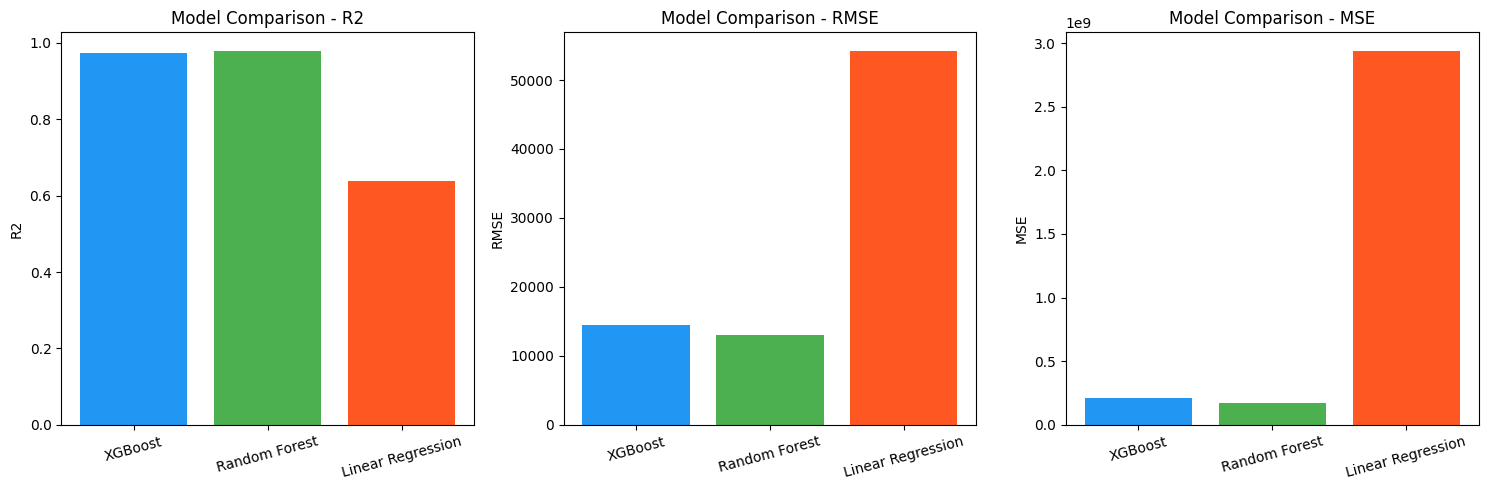

In [ ]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['R2', 'RMSE', 'MSE']
for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in results]
    axes[i].bar(results.keys(), values, color=['#2196F3', '#4CAF50', '#FF5722'])
    axes[i].set_title(f'Model Comparison - {metric}')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../results/figures/yield_model_comparison.png', dpi=300)
plt.show()

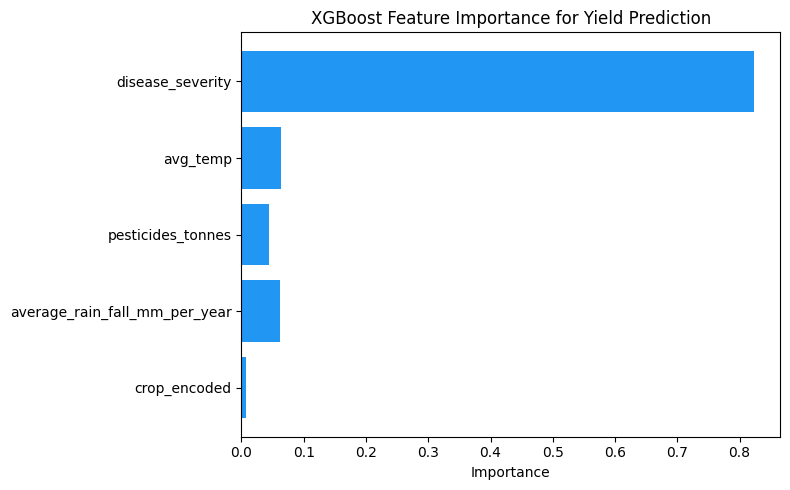


Feature Importances:
  disease_severity: 0.8237
  avg_temp: 0.0630
  average_rain_fall_mm_per_year: 0.0622
  pesticides_tonnes: 0.0444
  crop_encoded: 0.0067


In [ ]:
# XGBoost feature importance
xgb_model = models['XGBoost']
importances = xgb_model.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(features, importances, color='#2196F3')
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance for Yield Prediction')
plt.tight_layout()
plt.savefig('../results/figures/feature_importance.png', dpi=300)
plt.show()

print("\nFeature Importances:")
for f, imp in sorted(zip(features, importances), key=lambda x: -x[1]):
    print(f"  {f}: {imp:.4f}")

In [ ]:
# Full pipeline demo
# Simulate the full pipeline:
# Image → Keras classifies disease → fed into XGBoost → yield prediction

def predict_yield(crop, disease_class, rainfall, pesticides, temperature):
    severity = disease_yield_impact.get(disease_class, 0.0)
    crop_enc = le.transform([crop])[0]
    features_input = pd.DataFrame([[crop_enc, rainfall, pesticides, temperature, severity]], 
                               columns=features)
    predicted_yield = xgb_model.predict(features_input)[0]
    loss_pct = severity * 100
    print(f"\n🌱 Crop:            {crop}")
    print(f"🦠 Disease:         {disease_class}")
    print(f"⚠️  Severity:        {severity*100:.0f}% yield impact")
    print(f"🌧️  Rainfall:        {rainfall} mm/year")
    print(f"🌡️  Temperature:     {temperature}°C")
    print(f"📊 Predicted Yield: {predicted_yield:,.0f} hg/ha")
    return predicted_yield

# Example: Keras model detected Rice Leaf Blast
predict_yield('Rice, paddy', 'Rice___Leaf_Blast', rainfall=1200, pesticides=50, temperature=28)


🌱 Crop:            Rice, paddy
🦠 Disease:         Rice___Leaf_Blast
⚠️  Severity:        50% yield impact
🌧️  Rainfall:        1200 mm/year
🌡️  Temperature:     28°C
📊 Predicted Yield: 19,127 hg/ha


19127.242

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

# ── Dropdowns ────────────────────────────────────────────────────────
crop_options = ['Maize', 'Wheat', 'Rice, paddy', 'Potatoes']

disease_options = {
    'Maize':       ['Corn___Common_Rust', 'Corn___Leaf_Blight', 'Corn___Healthy'],
    'Wheat':       ['Wheat___Brown_Rust', 'Wheat___Yellow_Rust', 'Wheat___Healthy'],
    'Rice, paddy': ['Rice___Brown_Spot', 'Rice___Hispa', 'Rice___Leaf_Blast', 'Rice___Healthy'],
    'Potatoes':    ['Potato___Early_Blight', 'Potato___Late_Blight', 'Potato___Healthy'],
}

# ── Widgets ──────────────────────────────────────────────────────────
crop_dd = widgets.Dropdown(
    options=crop_options,
    description='Crop:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

disease_dd = widgets.Dropdown(
    options=disease_options['Maize'],
    description='Disease:',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='350px')
)

rainfall_slider = widgets.FloatSlider(
    value=1000, min=0, max=3000, step=50,
    description='Rainfall (mm):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

temp_slider = widgets.FloatSlider(
    value=25, min=0, max=50, step=0.5,
    description='Temperature (°C):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

pesticides_slider = widgets.FloatSlider(
    value=50, min=0, max=500, step=10,
    description='Pesticides (t):',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='400px')
)

predict_btn = widgets.Button(
    description='🌱 Predict Yield',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

# ── Update disease dropdown when crop changes ─────────────────────────
def on_crop_change(change):
    disease_dd.options = disease_options[change['new']]

crop_dd.observe(on_crop_change, names='value')

# ── Predict on button click ───────────────────────────────────────────
def on_predict(btn):
    with output:
        output.clear_output()
        crop      = crop_dd.value
        disease   = disease_dd.value
        rainfall  = rainfall_slider.value
        temp      = temp_slider.value
        pesticides = pesticides_slider.value

        severity  = disease_yield_impact.get(disease, 0.0)
        crop_enc  = le.transform([crop])[0]

        input_df = pd.DataFrame(
            [[crop_enc, rainfall, pesticides, temp, severity]],
            columns=features
        )

        predicted = xgb_model.predict(input_df)[0]
        loss_pct  = severity * 100
        adjusted  = predicted * (1 - severity)

        # Color based on severity
        if severity == 0:
            color = '🟢'
        elif severity < 0.3:
            color = '🟡'
        else:
            color = '🔴'

        print("=" * 45)
        print(f"  🌾 Crop:              {crop}")
        print(f"  🦠 Disease:           {disease.replace('___', ' ')}")
        print(f"  {color} Severity:          {loss_pct:.0f}% yield impact")
        print(f"  🌧️  Rainfall:           {rainfall:.0f} mm/year")
        print(f"  🌡️  Temperature:        {temp:.1f} °C")
        print(f"  🧪 Pesticides:         {pesticides:.0f} tonnes")
        print("-" * 45)
        print(f"  📊 Base Yield:         {predicted:,.0f} hg/ha")
        print(f"  📉 Adjusted Yield:     {adjusted:,.0f} hg/ha")
        print(f"  💰 Estimated Loss:     {predicted - adjusted:,.0f} hg/ha")
        print("=" * 45)

predict_btn.on_click(on_predict)

# ── Layout ────────────────────────────────────────────────────────────
title = widgets.HTML("<h3>🌿 Crop Yield Prediction Tool</h3>")
display(
    title,
    crop_dd,
    disease_dd,
    rainfall_slider,
    temp_slider,
    pesticides_slider,
    predict_btn,
    output
)

HTML(value='<h3>🌿 Crop Yield Prediction Tool</h3>')

Dropdown(description='Crop:', layout=Layout(width='350px'), options=('Maize', 'Wheat', 'Rice, paddy', 'Potatoe…

Dropdown(description='Disease:', layout=Layout(width='350px'), options=('Corn___Common_Rust', 'Corn___Leaf_Bli…

FloatSlider(value=1000.0, description='Rainfall (mm):', layout=Layout(width='400px'), max=3000.0, step=50.0, s…

FloatSlider(value=25.0, description='Temperature (°C):', layout=Layout(width='400px'), max=50.0, step=0.5, sty…

FloatSlider(value=50.0, description='Pesticides (t):', layout=Layout(width='400px'), max=500.0, step=10.0, sty…

Button(button_style='success', description='🌱 Predict Yield', layout=Layout(height='40px', width='200px'), sty…

Output()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, Image as IPImage
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import sys
sys.path.append('src')
from model_factory import get_model, MODEL_CONFIG

# ── Load best Keras model (ConvNeXtXLarge) ────────────────────────────
print("Loading ConvNeXtXLarge model...")
best_model, preprocess_func, input_size = get_model('ConvNeXtXLarge', num_classes=15)
best_model.load_weights('checkpoints/final_ConvNeXtXLarge.weights.h5')
print("Model loaded!")

# Class names matching your dataset
CLASS_NAMES = [
    'Corn___Common_Rust', 'Corn___Healthy', 'Corn___Leaf_Blight',
    'Invalid', 'Potato___Early_Blight', 'Potato___Healthy',
    'Potato___Late_Blight', 'Rice___Brown_Spot', 'Rice___Healthy',
    'Rice___Hispa', 'Rice___Leaf_Blast', 'Wheat___Brown_Rust',
    'Wheat___Healthy', 'Wheat___Yellow_Rust', 'Unknown'
]

# Crop mapping
disease_to_crop = {
    'Corn___Common_Rust':    'Maize',
    'Corn___Leaf_Blight':    'Maize',
    'Corn___Healthy':        'Maize',
    'Potato___Early_Blight': 'Potatoes',
    'Potato___Late_Blight':  'Potatoes',
    'Potato___Healthy':      'Potatoes',
    'Rice___Brown_Spot':     'Rice, paddy',
    'Rice___Hispa':          'Rice, paddy',
    'Rice___Leaf_Blast':     'Rice, paddy',
    'Rice___Healthy':        'Rice, paddy',
    'Wheat___Brown_Rust':    'Wheat',
    'Wheat___Yellow_Rust':   'Wheat',
    'Wheat___Healthy':       'Wheat',
    'Invalid':               'Maize',
}

# ── Widgets ───────────────────────────────────────────────────────────
upload_btn = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=False,
    description='📷 Upload Image',
    layout=widgets.Layout(width='250px')
)

rainfall_slider2 = widgets.FloatSlider(
    value=1000, min=0, max=3000, step=50,
    description='Rainfall (mm):',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='420px')
)

temp_slider2 = widgets.FloatSlider(
    value=25, min=0, max=50, step=0.5,
    description='Temperature (°C):',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='420px')
)

pesticides_slider2 = widgets.FloatSlider(
    value=50, min=0, max=500, step=10,
    description='Pesticides (t):',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='420px')
)

predict_btn2 = widgets.Button(
    description='🌱 Detect & Predict',
    button_style='success',
    layout=widgets.Layout(width='220px', height='40px')
)

output2 = widgets.Output()

# ── Predict ───────────────────────────────────────────────────────────
def on_predict_image(btn):
    with output2:
        output2.clear_output()

        if not upload_btn.value:
            print("⚠️  Please upload an image first.")
            return

        # Get uploaded image bytes
        uploaded_file = list(upload_btn.value.values())[0]
        img_bytes = uploaded_file['content']

        # Show the uploaded image
        display(IPImage(data=img_bytes, width=300))

        # Preprocess for model
        import io
        from PIL import Image as PILImage
        img = PILImage.open(io.BytesIO(img_bytes)).convert('RGB')
        img_resized = img.resize(input_size)
        img_array  = np.array(img_resized, dtype=np.float32)

        if preprocess_func:
            img_array = preprocess_func(img_array)

        img_array = np.expand_dims(img_array, axis=0)

        # Classify with Keras model
        preds      = best_model.predict(img_array, verbose=0)
        class_idx  = np.argmax(preds[0])
        confidence = preds[0][class_idx] * 100
        disease    = CLASS_NAMES[class_idx]
        crop       = disease_to_crop.get(disease, 'Maize')

        # Yield prediction
        severity   = disease_yield_impact.get(disease, 0.0)
        crop_enc   = le.transform([crop])[0]
        rainfall   = rainfall_slider2.value
        temp       = temp_slider2.value
        pesticides = pesticides_slider2.value

        input_df = pd.DataFrame(
            [[crop_enc, rainfall, pesticides, temp, severity]],
            columns=features
        )

        predicted = xgb_model.predict(input_df)[0]
        adjusted  = predicted * (1 - severity)
        loss_pct  = severity * 100

        if severity == 0:
            color = '🟢'
        elif severity < 0.3:
            color = '🟡'
        else:
            color = '🔴'

        print("=" * 50)
        print(f"  🔍 Detected Disease:   {disease.replace('___', ' ')}")
        print(f"  📊 Confidence:         {confidence:.1f}%")
        print(f"  🌾 Crop:               {crop}")
        print(f"  {color} Severity:           {loss_pct:.0f}% yield impact")
        print("-" * 50)
        print(f"  🌧️  Rainfall:            {rainfall:.0f} mm/year")
        print(f"  🌡️  Temperature:         {temp:.1f} °C")
        print(f"  🧪 Pesticides:          {pesticides:.0f} tonnes")
        print("-" * 50)
        print(f"  📈 Base Yield:          {predicted:,.0f} hg/ha")
        print(f"  📉 Adjusted Yield:      {adjusted:,.0f} hg/ha")
        print(f"  💰 Estimated Loss:      {predicted - adjusted:,.0f} hg/ha")
        print("=" * 50)

predict_btn2.on_click(on_predict_image)

# ── Display ───────────────────────────────────────────────────────────
title2 = widgets.HTML("<h3>🌿 Plant Disease Detection & Yield Prediction</h3><p>Upload a plant image to automatically detect disease and predict crop yield.</p>")
display(
    title2,
    upload_btn,
    rainfall_slider2,
    temp_slider2,
    pesticides_slider2,
    predict_btn2,
    output2
)